In [11]:
import json
import pandas as pd
import networkx as nx
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import os

In [12]:
def load_entities_with_fix(BASE_DIR):
    """
    Load entities, automatically fixing first-person narration issues.
    """
    FIXED_FILE = f"{BASE_DIR}.entities.fixed"
    ENT_FILE = f"{BASE_DIR}.entities"
    
    # If fixed file exists, use it
    if os.path.exists(FIXED_FILE):
        return pd.read_csv(FIXED_FILE, sep="\t", quoting=3)
    
    # Otherwise, load original and check if fix needed
    ents = pd.read_csv(ENT_FILE, sep="\t", quoting=3)
    ents_persons = ents[ents["cat"] == "PER"].copy()
    
    # Quick check: are there orphaned first-person pronouns?
    first_person = ents_persons[ents_persons["text"].str.lower().isin(['i', 'me', 'my', 'mine', 'myself'])]
    
    if len(first_person) > 100:  # Likely first-person novel
        # Find orphaned clusters (first-person but no proper nouns)
        orphaned = []
        for cluster_id in first_person["COREF"].value_counts().head(5).index:
            cluster = ents_persons[ents_persons["COREF"].astype(str) == str(cluster_id)]
            if (cluster["prop"] == "PROP").sum() == 0:
                orphaned.append((cluster_id, len(cluster)))
        
        if orphaned:
            print(f"\n  Detected first-person narration issue in {os.path.basename(BASE_DIR)}")
            print(f"   Found {len(orphaned)} orphaned pronoun clusters")
            
            # Find protagonist by looking for character with BOTH:
            # 1. Proper nouns (is a named character)
            # 2. Second-person pronouns
            
            ents_persons["COREF"] = ents_persons["COREF"].astype(str)
            
            # Count second-person pronouns per cluster
            second_person = ents_persons[ents_persons["text"].str.lower().isin(['you', 'your', 'yours', 'yourself'])]
            second_person_counts = second_person.groupby("COREF").size()
            
            # Get clusters with proper nouns
            cluster_stats = (
                ents_persons.groupby("COREF")
                .agg({
                    "text": "count",
                    "prop": lambda x: (x == "PROP").sum()
                })
                .rename(columns={"text": "n_mentions", "prop": "n_prop"})
            )
            
            # Add second-person counts
            cluster_stats["n_second_person"] = cluster_stats.index.map(
                lambda x: second_person_counts.get(x, 0)
            )
            
            # Protagonist = most second-person pronouns among named characters
            candidates = cluster_stats[cluster_stats["n_prop"] > 0].copy()
            protagonist = candidates.sort_values("n_second_person", ascending=False).index[0]
            
            # Get protagonist name
            protag_cluster = ents_persons[ents_persons["COREF"] == protagonist]
            protag_name = protag_cluster[protag_cluster["prop"] == "PROP"]["text"].value_counts().index[0]
            
            print(f"   Detected protagonist: Cluster {protagonist} ({protag_name})")
            print(f"   ({candidates.loc[protagonist, 'n_second_person']} 'you' pronouns)")
            
            # Fix the data
            ents_fixed = ents.copy()
            ents_fixed["COREF"] = ents_fixed["COREF"].astype(str)
            total_merged = 0
            for cluster_id, count in orphaned:
                ents_fixed.loc[ents_fixed["COREF"] == str(cluster_id), "COREF"] = protagonist
                total_merged += count
                print(f"   Merged {count} mentions from cluster {cluster_id}")
            
            # Save fixed file
            ents_fixed.to_csv(FIXED_FILE, sep="\t", index=False, quoting=3)
            
            before = len(ents_persons[ents_persons["COREF"] == protagonist])
            after = len(ents_fixed[ents_fixed["COREF"].astype(str) == protagonist])
            print(f"    {protag_name}: {before} → {after} mentions (+{after-before})")
            print(f"    Saved fixed entities to {FIXED_FILE}\n")
            
            return ents_fixed
    
    # No fix needed
    return ents

In [13]:
def build_co_network_named(BASE_DIR, min_freq=15, edge_min=2, title = ""):
    CHAR_FILE = f"{BASE_DIR}.characters.json"
    ENT_FILE  = f"{BASE_DIR}.entities"
    TOK_FILE  = f"{BASE_DIR}.tokens"

    # Load character dictionary
    with open(CHAR_FILE, "r") as f:
        data = json.load(f)

    id2name = {
        str(char["character_id"]): char["canonical_name"].title()
        for char in data["characters"]
    }
    # Load ENT file
    ents = load_entities_with_fix(BASE_DIR)

    # Filter: only person entities AND matching proper mention
    mask = (ents["cat"] == "PER") & (ents["prop"] == "PROP")
    pers = ents[mask].copy()

    # Ensure COREF is string
    pers["COREF"] = pers["COREF"].astype(str)

    # Map coreference cluster IDs to canonical names
    pers["character"] = pers["COREF"].map(id2name)

    # Drop mentions with no linked coref cluster
    pers = pers.dropna(subset=["character"])
    tokens = pd.read_csv(TOK_FILE, sep="\t", quoting=3)

    # Align each entity to its paragraph
    pers = pers.merge(
        tokens[["token_ID_within_document", "paragraph_ID"]],
        left_on="start_token",
        right_on="token_ID_within_document",
        how="left"
    )
    cooccur = Counter()

    for _, group in pers.groupby("paragraph_ID"):
        chars = sorted(group["character"].unique())
        for i in range(len(chars)):
            for j in range(i+1, len(chars)):
                cooccur[(chars[i], chars[j])] += 1
    G = nx.Graph()

    for (a, b), w in cooccur.items():
        G.add_edge(a, b, weight=w)
    edges = [
        {"source": a, "target": b, "weight": data["weight"]}
        for a, b, data in G.edges(data=True)
    ]

    df_edges = pd.DataFrame(edges)
    df_edges.to_csv("character_network.csv", index=False)
    # Character frequency for node sizing
    freq = pers["character"].value_counts().to_dict()

    min_size = 300
    max_size = 3000
    sizes = {
        char: min_size + (freq[char] / max(freq.values())) * (max_size - min_size)
        for char in freq
    }

    core_chars = [c for c, f in freq.items() if f >= min_freq]

    Gf = G.subgraph(core_chars).copy()

    edges_to_remove = [(u, v) for u, v, w in Gf.edges(data="weight") if w < edge_min]
    Gf.remove_edges_from(edges_to_remove)
    Gf.remove_nodes_from(list(nx.isolates(Gf)))

    # Layout
    pos = nx.spring_layout(Gf, k=1.2, iterations=200, seed=42)

    plt.figure(figsize=(14, 14))

    # Nodes
    nx.draw_networkx_nodes(
        Gf, pos,
        node_size=[sizes[n] for n in Gf.nodes()],
        node_color="skyblue",
        edgecolors="black",
        linewidths=1.2
    )

    # Edges
    weights = [Gf[u][v]['weight'] for u, v in Gf.edges()]
    nx.draw_networkx_edges(
        Gf, pos,
        width=[w * 0.15 for w in weights],
        alpha=0.25
    )

    # Labels
    nx.draw_networkx_labels(
        Gf, pos,
        font_size=10,
        font_family="serif",
        bbox=dict(boxstyle='round,pad=0.2', facecolor="skyblue",
                edgecolor="azure", alpha = 1)
    )

    plt.title(f"{title} Character Co-occurrence Network", fontsize=18)
    plt.axis("off")
    plt.show()
    
def build_total_network(BASE_DIR, min_freq=15, edge_min=2, title = ""):
    '''Build character co-occurrence network using all mention types'''
    TOK_FILE  = f"{BASE_DIR}.tokens"
    tokens = pd.read_csv(TOK_FILE, sep="\t", quoting=3)

    ents = load_entities_with_fix(BASE_DIR)
    ents = ents[ents["cat"] == "PER"].copy()
    ents["COREF"] = ents["COREF"].astype(str)

    cluster_summary = (
        ents.groupby("COREF")
        .apply(lambda df: pd.Series({
            "n_mentions": len(df),
            "n_prop":     (df["prop"] == "PROP").sum(),
            "n_pron":     (df["prop"] == "PRON").sum(),
            "n_nom":      (df["prop"] == "NOM").sum(),
            "top_text":   top_text_pref_prop(df)
        }), include_groups=False)
        .reset_index()
    )

    clean_clusters = cluster_summary[cluster_summary["n_prop"] > 0].copy()
    coref_to_name = dict(zip(clean_clusters["COREF"], clean_clusters["top_text"]))

    ents["character"] = ents["COREF"].map(coref_to_name)
    ents = ents.dropna(subset=["character"])

    ents = ents.merge(
        tokens[["token_ID_within_document", "paragraph_ID"]],
        left_on="start_token",
        right_on="token_ID_within_document",
        how="left"
    )

    cooccur = Counter()

    for pid, group in ents.groupby("paragraph_ID"):
        chars = sorted(group["character"].unique())
        for i in range(len(chars)):
            for j in range(i+1, len(chars)):
                cooccur[(chars[i], chars[j])] += 1

    G = nx.Graph()

    for (a, b), w in cooccur.items():
        G.add_edge(a, b, weight=w)

    freq = ents["character"].value_counts().to_dict()

    min_size = 300
    max_size = 3000
    sizes = {
        char: min_size + (freq[char] / max(freq.values())) * (max_size - min_size)
        for char in freq
    }

    core_chars = [c for c, f in freq.items() if f >= min_freq]

    Gf = G.subgraph(core_chars).copy()
    edges_to_remove = [(u, v) for u, v, w in Gf.edges(data="weight") if w < edge_min]
    Gf.remove_edges_from(edges_to_remove)
    Gf.remove_nodes_from(list(nx.isolates(Gf)))

    # Layout
    pos = nx.spring_layout(Gf, k=1.2, iterations=200, seed=42)

    plt.figure(figsize=(14, 14))

    # Nodes
    nx.draw_networkx_nodes(
        Gf, pos,
        node_size=[sizes[n] for n in Gf.nodes()],
        node_color="skyblue",
        edgecolors="black",
        linewidths=1.2
    )

    # Edges
    weights = [Gf[u][v]['weight'] for u, v in Gf.edges()]
    nx.draw_networkx_edges(
        Gf, pos,
        width=[w * 0.15 for w in weights],
        alpha=0.25
    )

    # Labels
    nx.draw_networkx_labels(
        Gf, pos,
        font_size=10,
        font_family="serif",
        bbox=dict(boxstyle='round,pad=0.2', facecolor="skyblue",
                edgecolor="azure", alpha = 1)
    )

    plt.title(f"{title} Character Total Mention Network", fontsize=18)
    plt.axis("off")
    plt.show()
    
def build_dialogue_network(BASE_DIR, min_freq=5, edge_min=1, title = ""):

    ENT_FILE  = f"{BASE_DIR}.entities"
    QUOT_FILE = f"{BASE_DIR}.quotes"

    ents = load_entities_with_fix(BASE_DIR)
    ents = ents[ents["cat"] == "PER"].copy()
    ents["COREF"] = ents["COREF"].astype(str)

    # Build canonical cluster summary
    cluster_summary = (
        ents.groupby("COREF")
        .apply(lambda df: pd.Series({
            "n_mentions": len(df),
            "n_prop":     (df["prop"] == "PROP").sum(),
            "n_pron":     (df["prop"] == "PRON").sum(),
            "n_nom":      (df["prop"] == "NOM").sum(),
            "top_text":   top_text_pref_prop(df)
        }), include_groups=False)
        .reset_index()
    )

    # Keep ONLY clusters with at least one PROP, canonical named characters
    clean_clusters = cluster_summary[cluster_summary["n_prop"] > 0].copy()

    # Canonical mapping: COREF cluster to best name
    coref_to_name = dict(zip(clean_clusters["COREF"], clean_clusters["top_text"]))

    allowed_corefs = set(coref_to_name.keys())

    # Attach canonical character name to ents (optional but consistent)
    ents["character"] = ents["COREF"].map(coref_to_name)

    quotes = pd.read_csv(QUOT_FILE, sep="\t", quoting=3)
    quotes["char_id"] = quotes["char_id"].astype(float).astype("Int64")
    quotes["char_id_str"] = quotes["char_id"].astype(str)

    # Keep only quotes whose COREF cluster has a canonical name
    quotes = quotes[quotes["char_id_str"].isin(allowed_corefs)].copy()

    # Assign speaker name via canonical cluster mapping
    quotes["speaker"] = quotes["char_id_str"].map(coref_to_name)

    # Remove unmapped rows
    quotes = quotes.dropna(subset=["speaker"])

    # Sort chronologically
    quotes = quotes.sort_values("quote_start")

    #
    # Build edges (turn-taking)
    edges = Counter()
    prev = None

    for sp in quotes["speaker"]:
        if prev and sp != prev:
            edges[tuple(sorted([prev, sp]))] += 1
        prev = sp

    # Build graph
    G = nx.Graph()
    for (a, b), w in edges.items():
        G.add_edge(a, b, weight=w)

    # Remove weak edges
    G.remove_edges_from([(u, v) for u, v, w in G.edges(data="weight") if w < edge_min])

    # Remove isolates
    G.remove_nodes_from(list(nx.isolates(G)))

    speak_freq = quotes["speaker"].value_counts().to_dict()

    # Keep only characters with enough quotes
    core_chars = [c for c, f in speak_freq.items() if f >= min_freq]
    Gf = G.subgraph(core_chars).copy()

    max_freq = max(speak_freq.values()) if speak_freq else 1

    node_sizes = [
        300 + (speak_freq[n] / max_freq) * (3000 - 300)
        for n in Gf.nodes()
    ]

    if len(Gf.edges()) > 0:
        weights = [Gf[u][v]["weight"] for u, v in Gf.edges()]
        max_w = max(weights)
        edge_widths = [(w / max_w) * 10 for w in weights]
    else:
        edge_widths = []


    pos = nx.spring_layout(Gf, k=1.2, iterations=200, seed=42)

    plt.figure(figsize=(14, 14))
    nx.draw_networkx_nodes(
        Gf, pos, node_size=node_sizes,
        node_color="skyblue", edgecolors="black", linewidths=1.2
    )
    nx.draw_networkx_edges(Gf, pos, width=edge_widths, alpha=0.35)
    nx.draw_networkx_labels(
        Gf, pos, font_size=10,
        bbox=dict(boxstyle="round,pad=0.2",
                  facecolor="skyblue", edgecolor="azure", alpha=1)
    )
    plt.title(f"{title} Dialogue Turn Network", fontsize=18)
    plt.axis("off")
    plt.show()

def top_text_pref_prop(df):
    # Return most common mention texts, filtering proper nouns
    prop_mentions = df.loc[df["prop"] == "PROP", "text"]
    if len(prop_mentions) > 0:
        return prop_mentions.value_counts().idxmax()
    return df["text"].value_counts().idxmax()

def show_cluster(coref_id, ents):
    df = ents[ents["COREF"].astype(str) == str(coref_id)]
    return df[["COREF", "prop", "cat", "text", "start_token"]].head(10)

def get_cluster_summary(BASE_DIR):
    ENT_FILE  = f"{BASE_DIR}.entities"
    ents = pd.read_csv(ENT_FILE, sep="\t", quoting=3)
    ents = ents[ents["cat"] == "PER"].copy()
    ents["COREF"] = ents["COREF"].astype(str)

    cluster_summary = (
        ents.groupby("COREF")
        .apply(lambda df: pd.Series({
            "n_mentions": len(df),
            "n_prop":     (df["prop"] == "PROP").sum(),
            "n_pron":     (df["prop"] == "PRON").sum(),
            "n_nom":      (df["prop"] == "NOM").sum(),
            "top_text":   top_text_pref_prop(df)
        }), include_groups=False)
        .reset_index()
    )

    cluster_summary_sorted = cluster_summary.sort_values(
        "n_mentions", ascending=False
    )
    return cluster_summary_sorted

def get_clean_ambig(BASE_DIR):
    # This function separates clusters into clean (with proper noun mentions) and ambiguous (without proper noun mentions)
    ENT_FILE  = f"{BASE_DIR}.entities"
    ents = pd.read_csv(ENT_FILE, sep="\t", quoting=3)
    ents = ents[ents["cat"] == "PER"].copy()
    ents["COREF"] = ents["COREF"].astype(str)

    cluster_summary = (
        ents.groupby("COREF")
        .apply(lambda df: pd.Series({
            "n_mentions": len(df),
            "n_prop":     (df["prop"] == "PROP").sum(),
            "n_pron":     (df["prop"] == "PRON").sum(),
            "n_nom":      (df["prop"] == "NOM").sum(),
            "top_text":   top_text_pref_prop(df)
        }), include_groups=False)
        .reset_index()
    )

    clean_clusters = cluster_summary[cluster_summary["n_prop"] > 0].copy()
    ambig_clusters = cluster_summary[cluster_summary["n_prop"] == 0].copy()
    clean_sorted = clean_clusters.sort_values(
        "n_mentions", ascending=False
    )
    ambig_sorted = ambig_clusters.sort_values(
        "n_mentions", ascending=False
    )
    return clean_sorted, ambig_sorted

def get_duplicate_clusters(BASE_DIR):
    ENT_FILE  = f"{BASE_DIR}.entities"
    ents = pd.read_csv(ENT_FILE, sep="\t", quoting=3)
    ents = ents[ents["cat"] == "PER"].copy()
    ents["COREF"] = ents["COREF"].astype(str)

    cluster_summary = (
        ents.groupby("COREF")
        .apply(lambda df: pd.Series({
            "n_mentions": len(df),
            "n_prop":     (df["prop"] == "PROP").sum(),
            "n_pron":     (df["prop"] == "PRON").sum(),
            "n_nom":      (df["prop"] == "NOM").sum(),
            "top_text":   top_text_pref_prop(df)
        }), include_groups=False)
        .reset_index()
    )

    clean_clusters = cluster_summary[cluster_summary["n_prop"] > 0].copy()

    duplicates = clean_clusters.groupby("top_text")["COREF"].apply(list)
    dupe_names = duplicates[duplicates.apply(len) > 1]
    return dupe_names

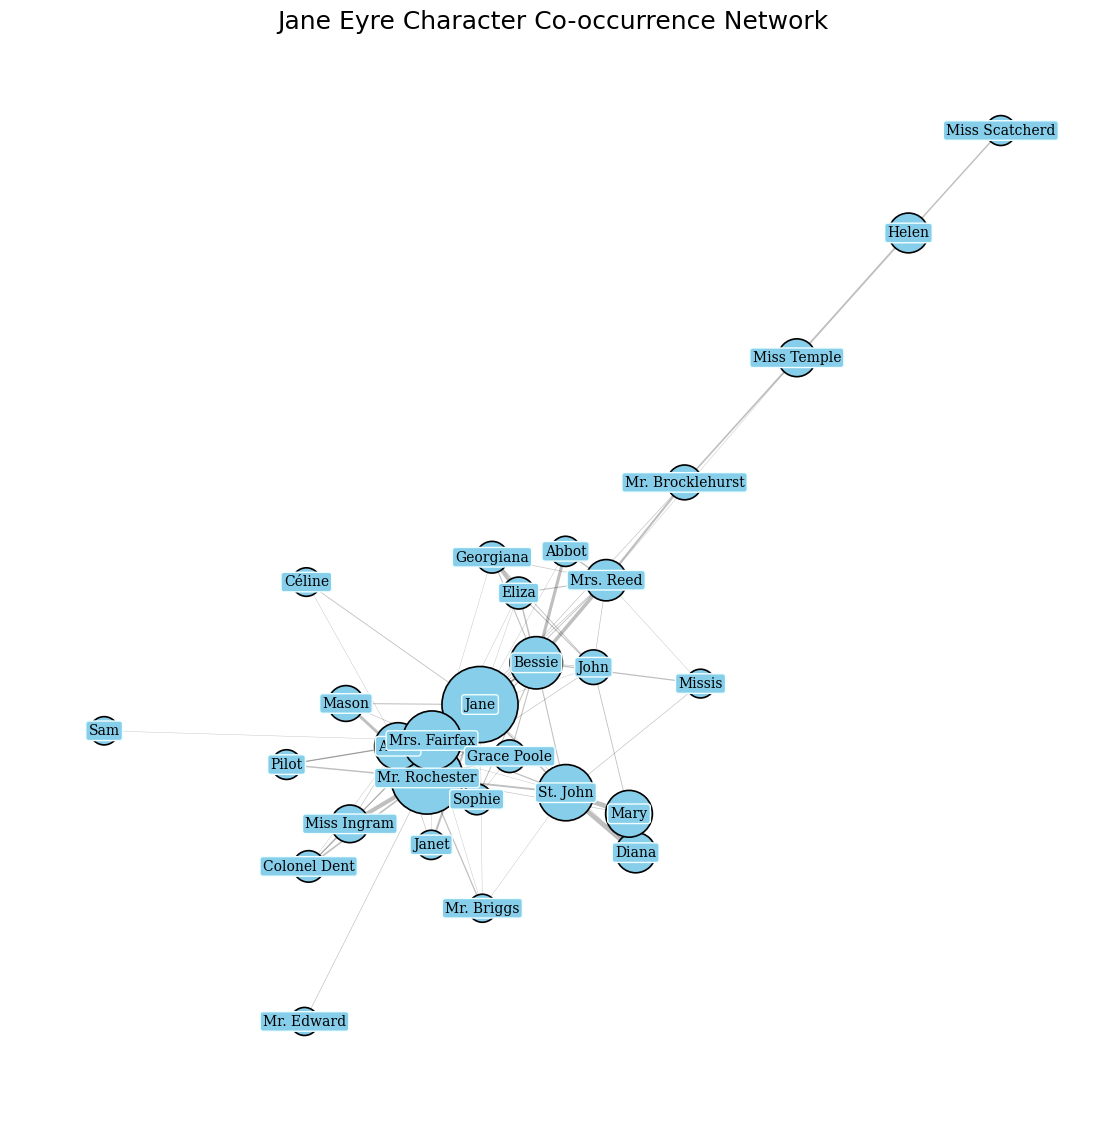

In [7]:
BASE = "../jane/jane_eyre"
build_co_network_named(BASE, min_freq=15, edge_min=2, title="Jane Eyre")

# To get cluster summary
summary_df = get_cluster_summary(BASE)
summary_df.to_csv("cluster_summary_pride.csv", index=False)
clean_df, ambig_df = get_clean_ambig(BASE)
clean_df.to_csv("clean_clusters_pride.csv", index=False)
ambig_df.to_csv("ambiguous_clusters_pride.csv", index=False)

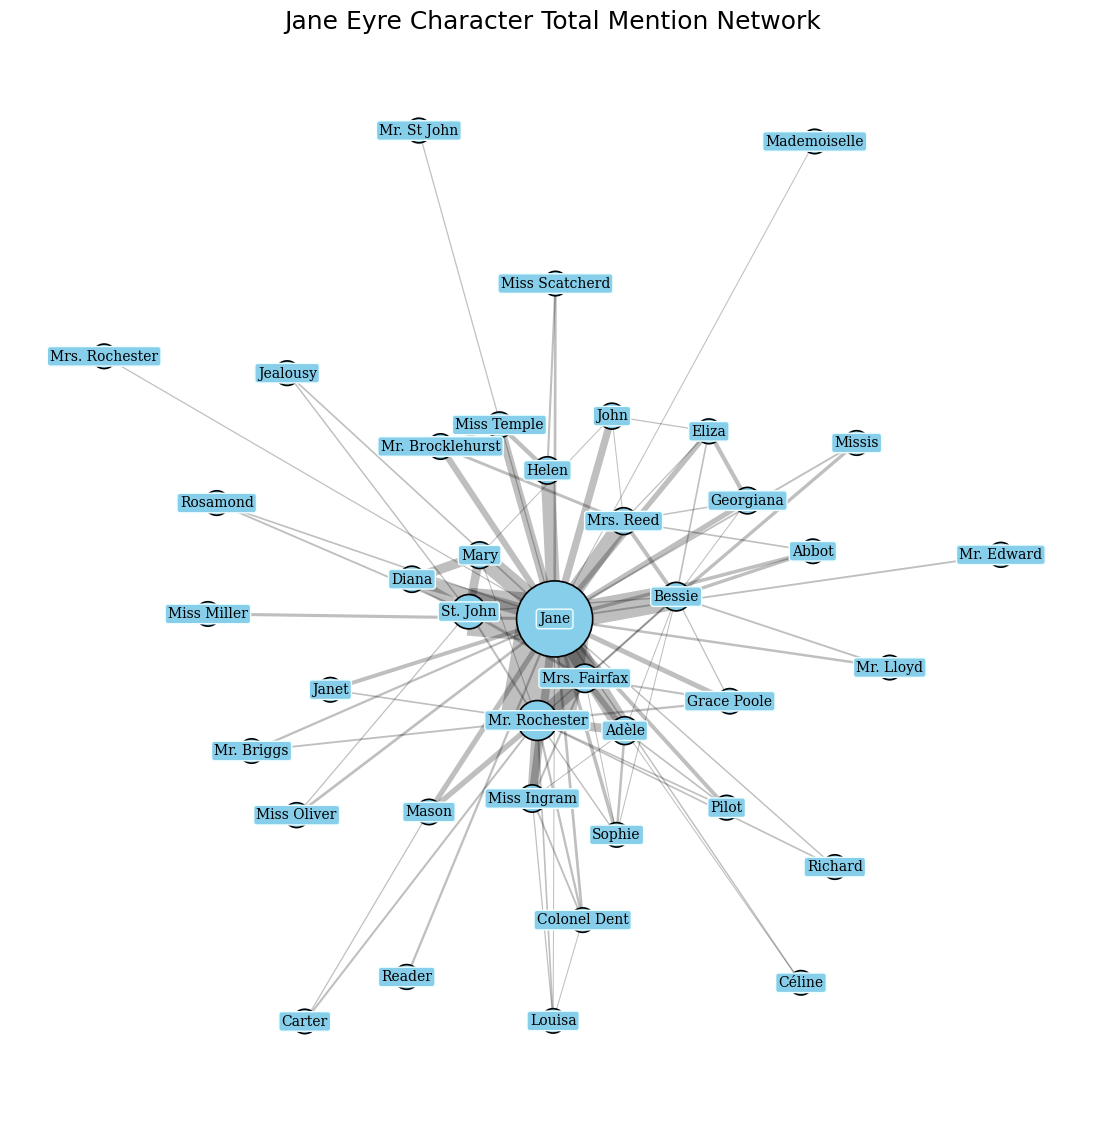

In [23]:
BASE = "../jane/jane_eyre"
build_total_network(BASE, min_freq=30, edge_min=5, title="Jane Eyre")

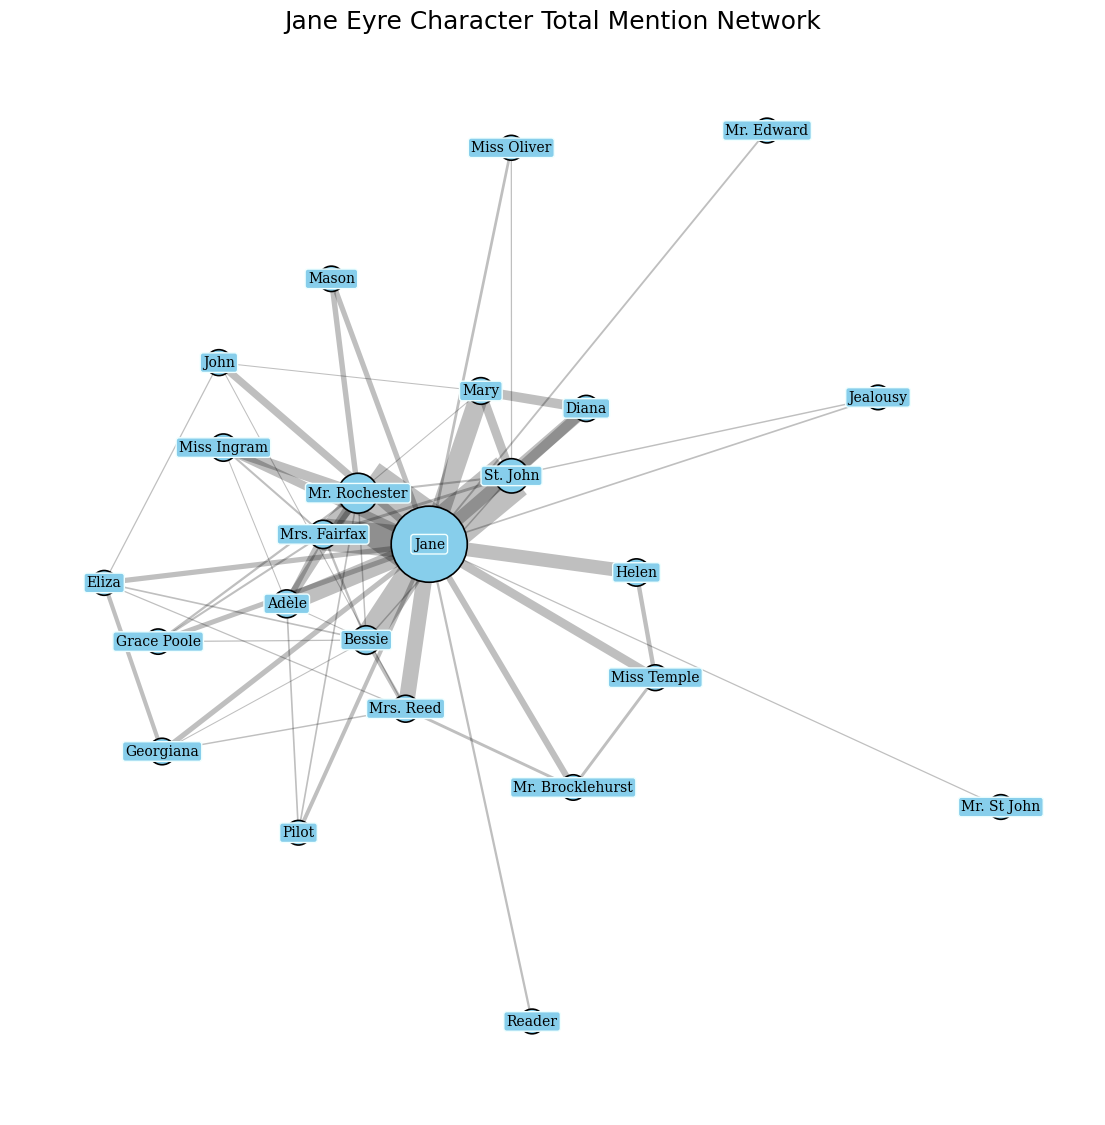

In [ ]:
BASE = "../jane/jane_eyre"
build_total_network(BASE, min_freq=50, edge_min=5, title="Jane Eyre")

/tmp/ipykernel_2560870/1263470735.py:221: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


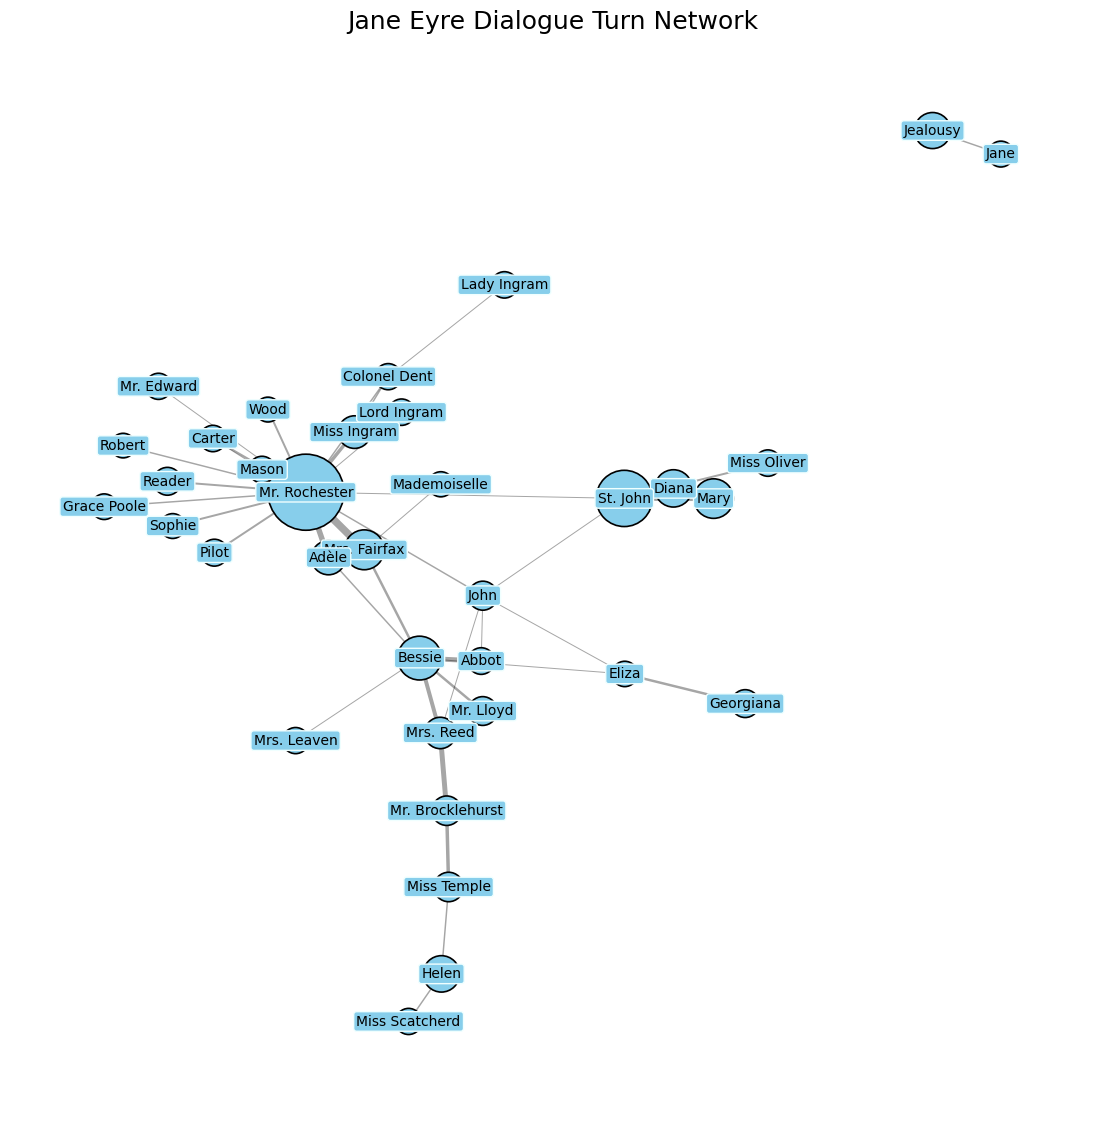

In [22]:
BASE = "../jane/jane_eyre"
build_dialogue_network(BASE, min_freq=2, edge_min=2, title="Jane Eyre")

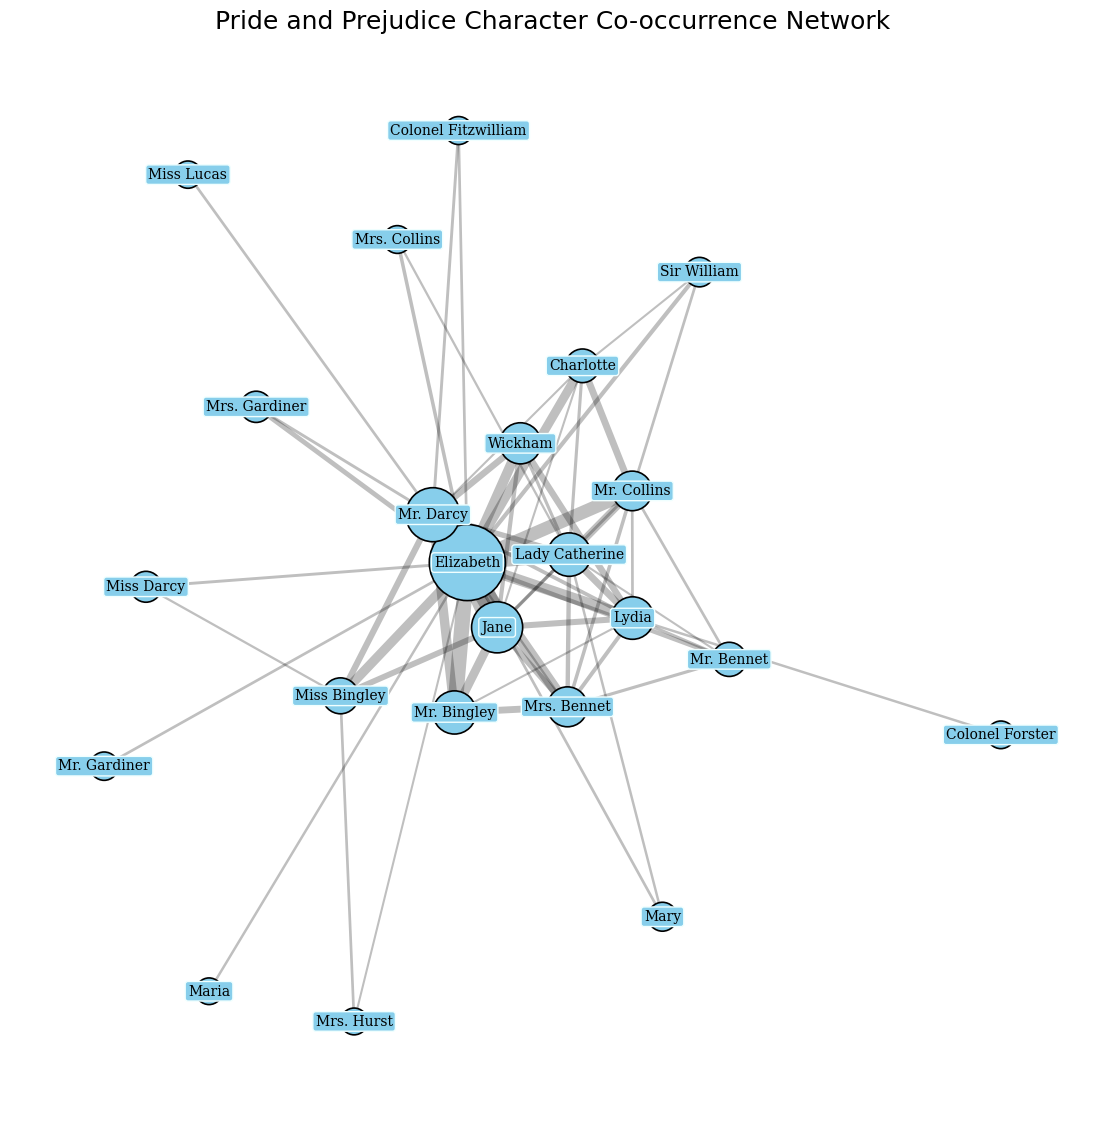

In [26]:
BASE = "../results/output/pride"
build_co_network_named(BASE, min_freq=10, edge_min=10, title="Pride and Prejudice")

/tmp/ipykernel_2560870/1263470735.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


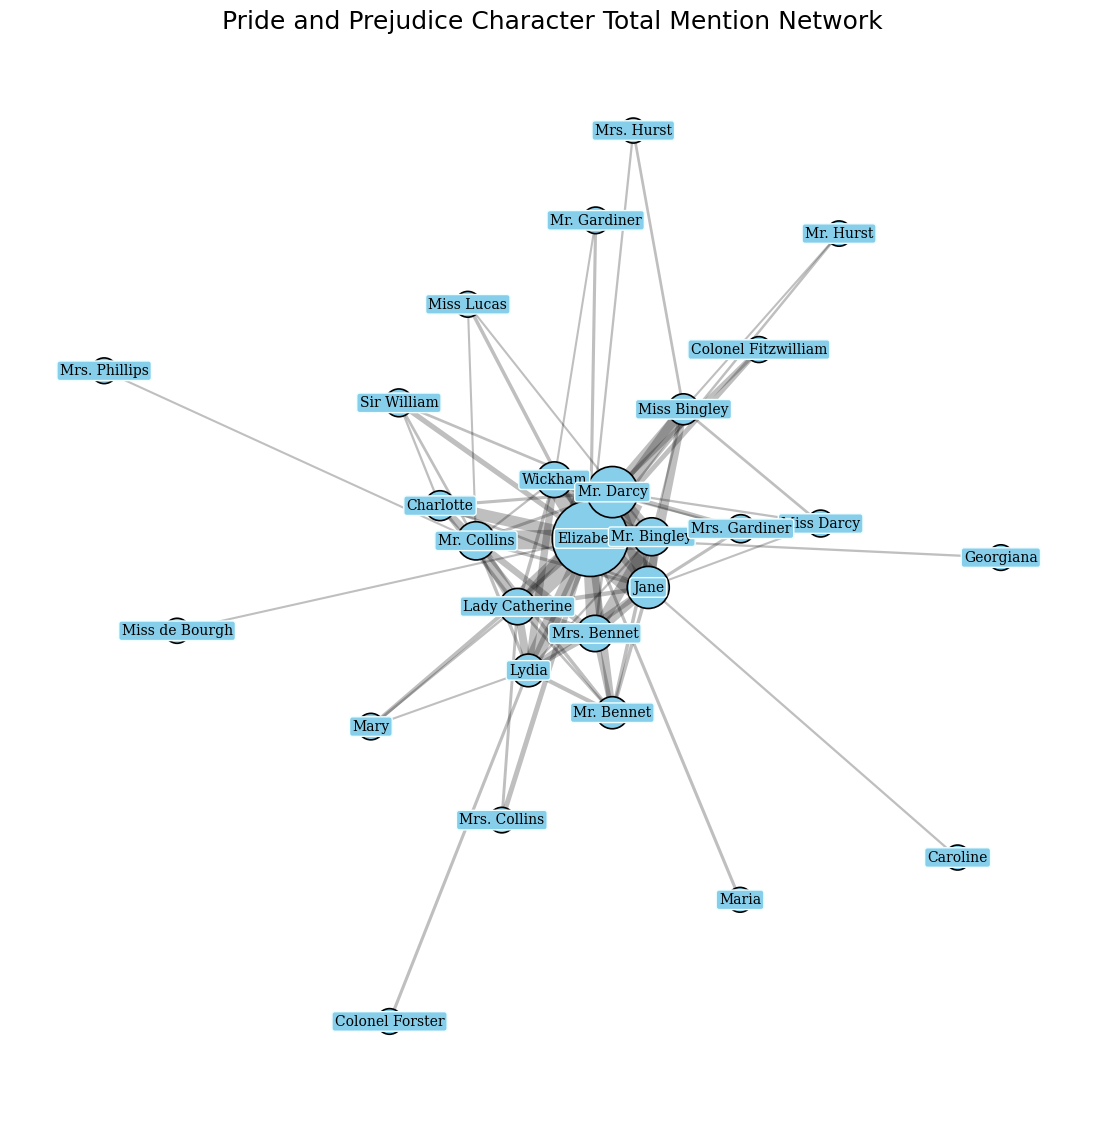

In [27]:
BASE = "../results/output/pride"
build_total_network(BASE, min_freq=25, edge_min=10, title="Pride and Prejudice")

/tmp/ipykernel_2560870/1263470735.py:221: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


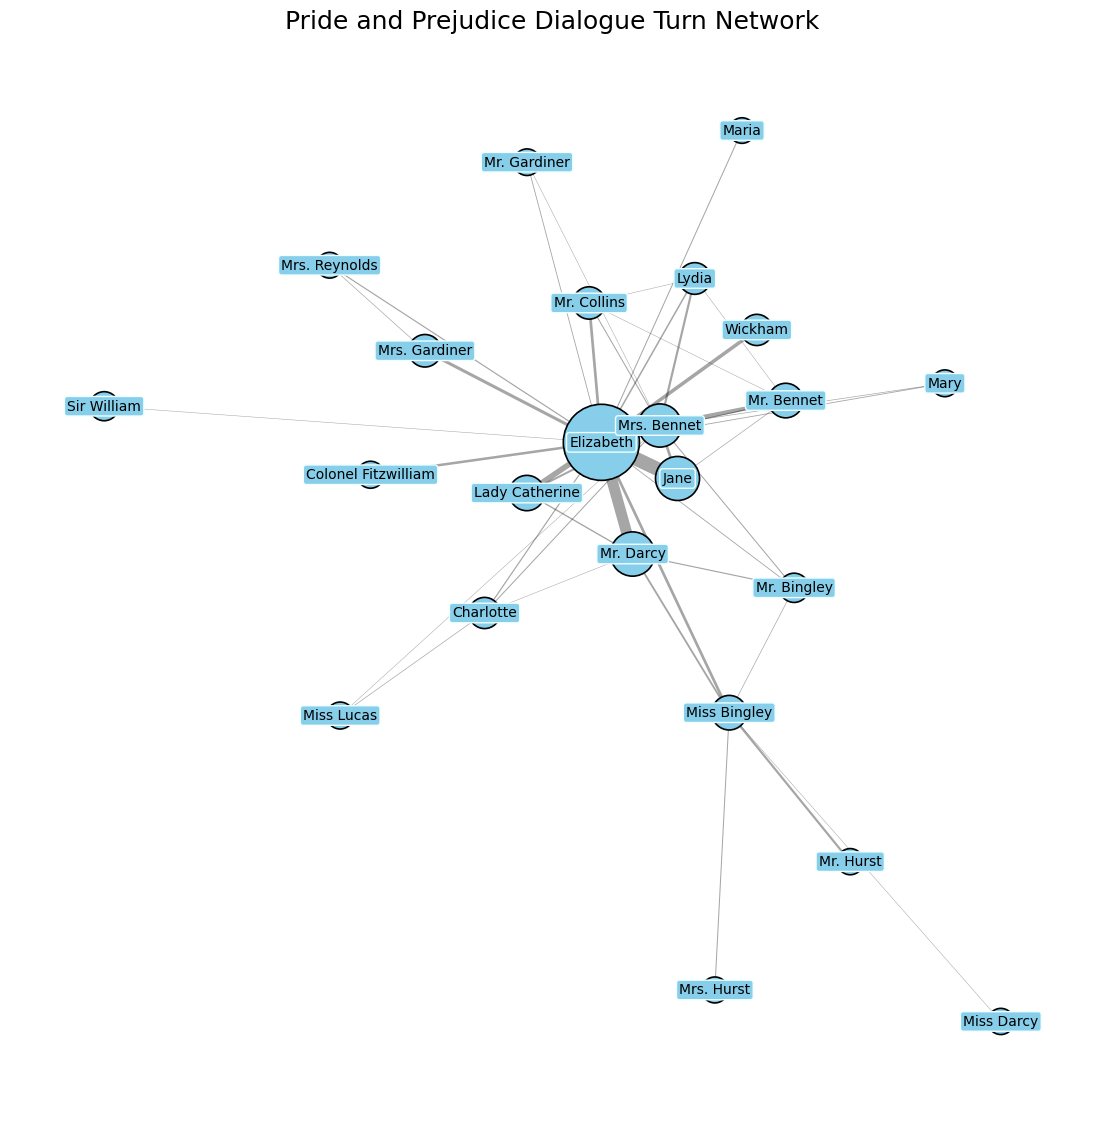

In [28]:
BASE = "../results/output/pride"
build_dialogue_network(BASE, min_freq=1, edge_min=3, title="Pride and Prejudice")

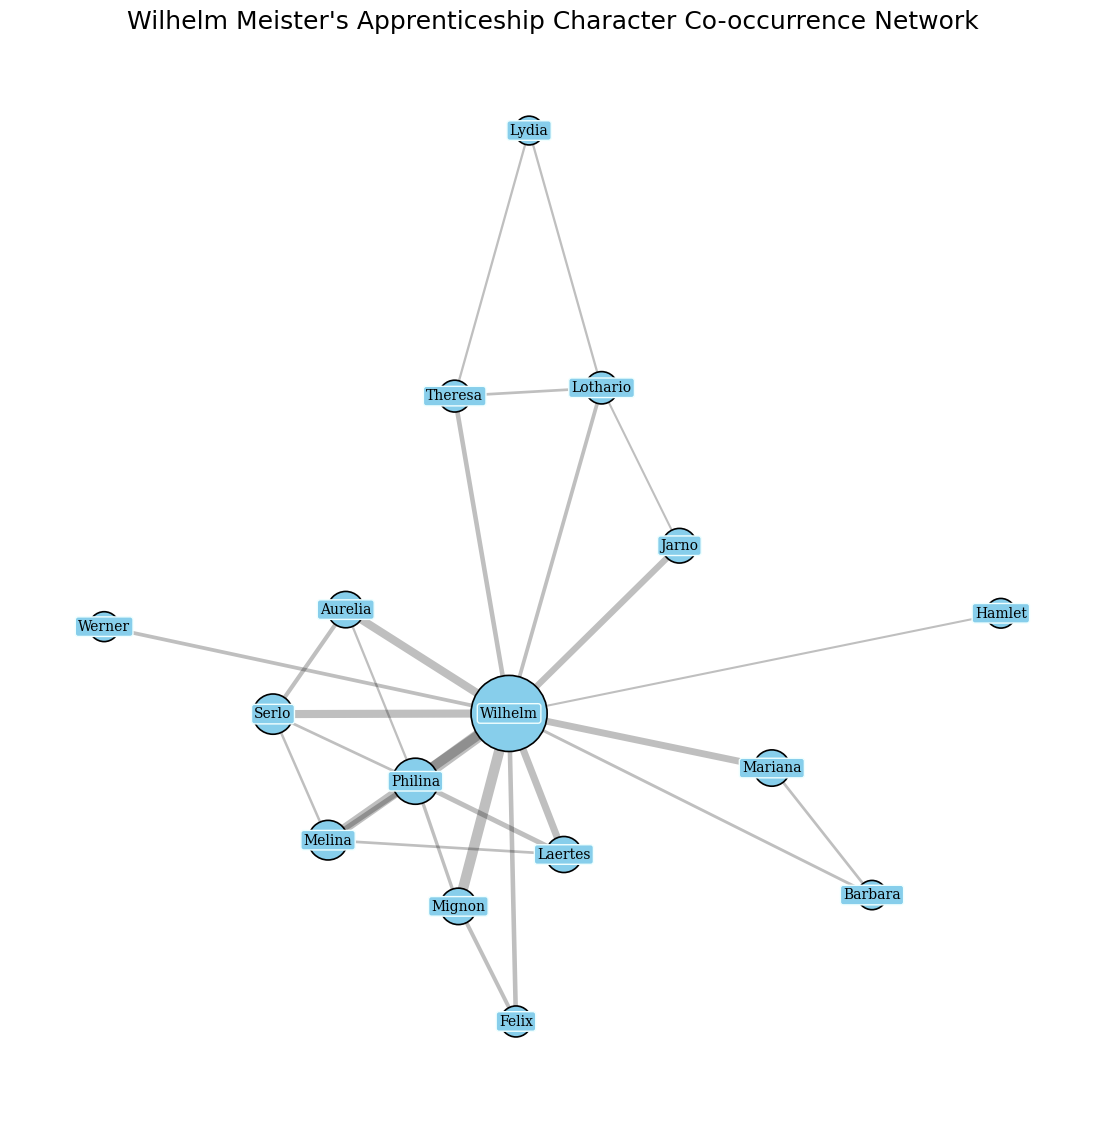

In [29]:
BASE = "../wilhelm/wilhelm_meisters"
build_co_network_named(BASE, min_freq=10, edge_min=10, title="Wilhelm Meister's Apprenticeship")

/tmp/ipykernel_2560870/1263470735.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


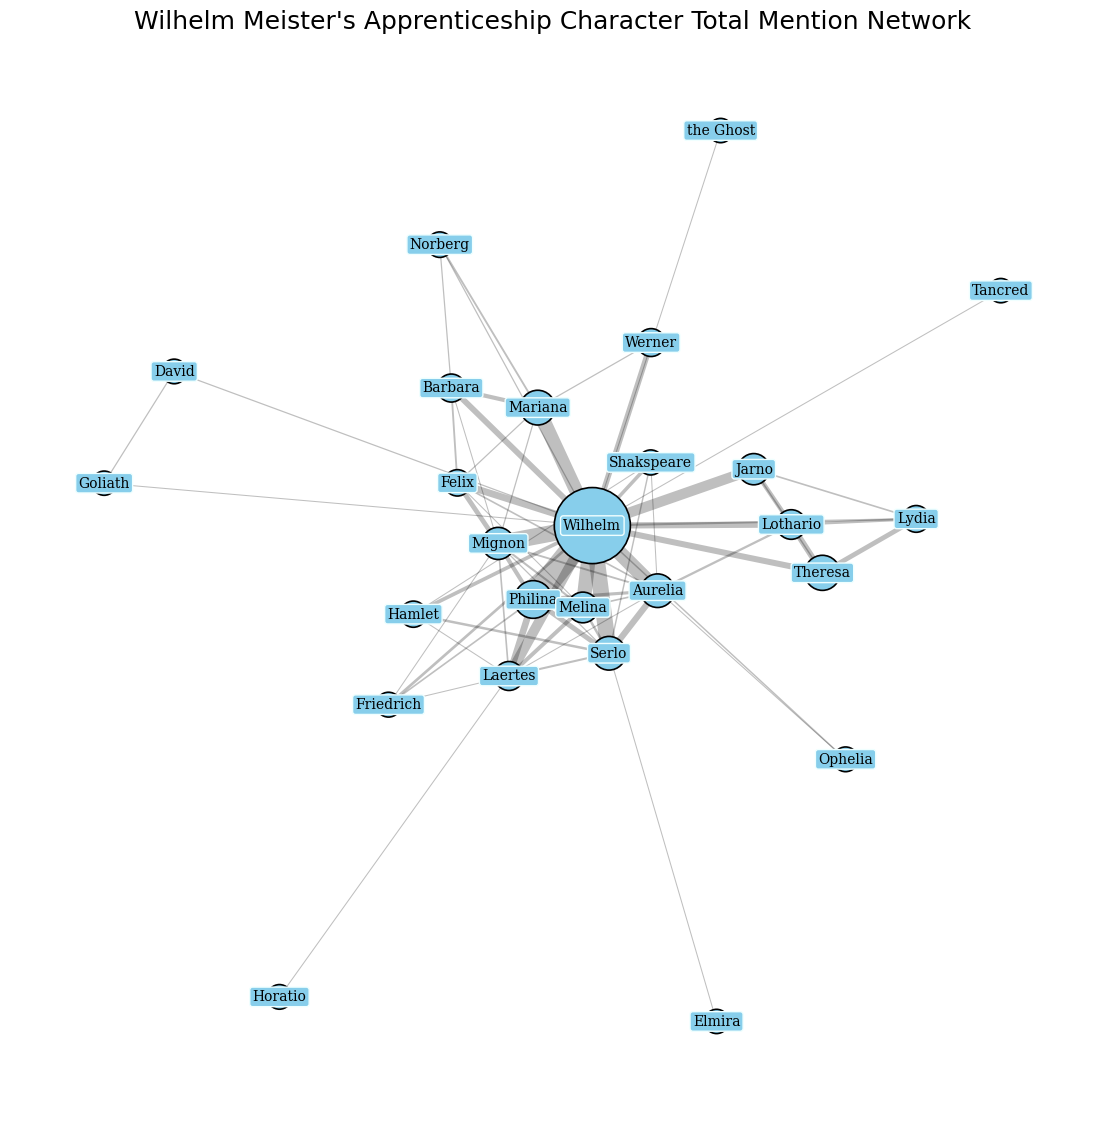

In [30]:
BASE = "../wilhelm/wilhelm_meisters"
build_total_network(BASE, min_freq=5, edge_min=5, title="Wilhelm Meister's Apprenticeship")

/tmp/ipykernel_2560870/1263470735.py:221: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: pd.Series({


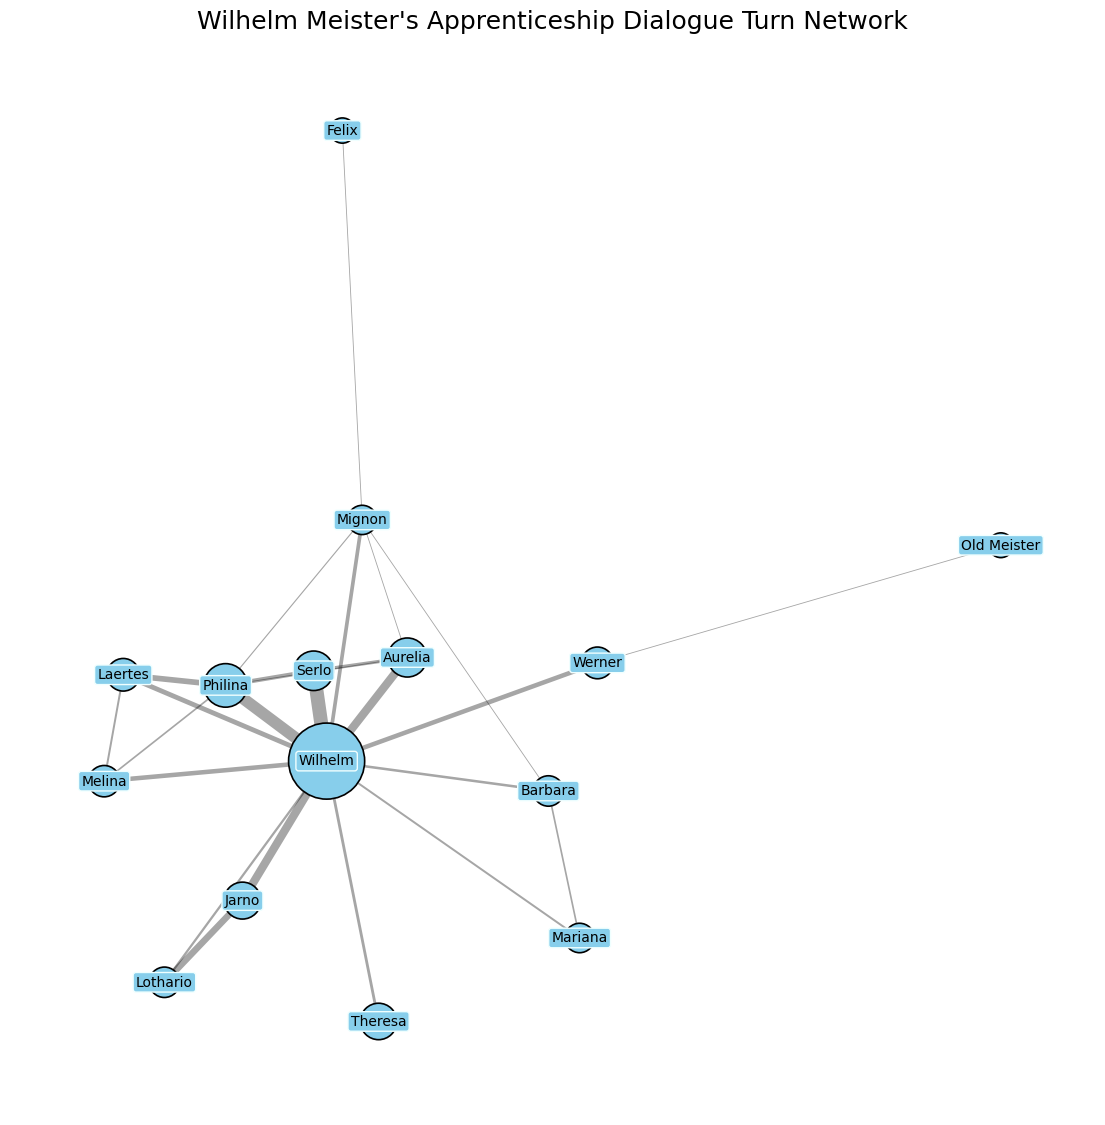

In [31]:
BASE = "../wilhelm/wilhelm_meisters"
build_dialogue_network(BASE, min_freq=1, edge_min=3, title="Wilhelm Meister's Apprenticeship")

In [51]:
#see if clean sorted has any character with top_Text = "mr."
mr = clean_sorted[clean_sorted["top_text"].str.lower() == "mr."]
print(mr)

     COREF  n_mentions  n_prop  n_pron  n_nom top_text
2188   786           1       1       0      0      Mr.
288   1669           1       1       0      0      Mr.
1945  5144           1       1       0      0      Mr.
1895  5034           1       1       0      0      Mr.
1707  4606           1       1       0      0      Mr.
170   1384           1       1       0      0      Mr.
227   1533           1       1       0      0      Mr.
2220   842           1       1       0      0      Mr.
1488  4158           1       1       0      0      Mr.
393   1918           1       1       0      0      Mr.
366   1843           1       1       0      0      Mr.
704   2647           1       1       0      0      Mr.
555   2281           1       1       0      0      Mr.
542   2251           1       1       0      0      Mr.
539   2247           1       1       0      0      Mr.
481   2129           1       1       0      0      Mr.
478   2120           1       1       0      0      Mr.
460   2095